In [32]:
from typing import List, TypedDict
from langgraph.graph import StateGraph, START, END
# StateGraph is a framework that help to design and manage the flow of tasks using graph structure.

In [33]:
class AgentState(TypedDict):
    num1: int
    num2: int
    num3: int
    num4: int
    operator1: str
    operator2: str
    final_num1: int
    final_num2: int

In [34]:
def adder1(state: AgentState) -> AgentState:
    """This node add two numbers"""
    state['final_num1'] = state['num1'] + state['num2']
    return state
def subtractor1(state: AgentState) -> AgentState:
    """This node subtract two numbers"""
    state['final_num1'] = state['num1'] - state['num2']
    return state
def decision_node1(state: AgentState) -> str: # This node is returning the edge not state!!!
    """This is the router node"""
    if state['operator1'] == "+":
        return 'addition-operation'
    elif state['operator1'] == "-":
        return 'subtraction-operation'
def decision_node2(state: AgentState) -> str: # This node is returning the edge not state!!!
    """This is the second router node"""
    if state['operator2'] == "+":
        return 'addition-operation2'
    elif state['operator2'] == "-":
        return 'subtraction-operation2'
def adder2(state: AgentState) -> AgentState:
    """This node add two numbers"""
    state['final_num2'] = state['num3'] + state['num4']
    return state
def subtractor2(state: AgentState) -> AgentState:
    """This node subtract two numbers"""
    state['final_num2'] = state['num3'] - state['num4']
    return state

In [35]:
graph = StateGraph(AgentState)
graph.add_node('router1', lambda state: state)  # Passthrough
graph.add_node('add-node', adder1)
graph.add_node('subtract-node', subtractor1)

graph.add_node('router2', lambda state: state)  # Passthrough
graph.add_node('add-node2', adder2)
graph.add_node('subtract-node2', subtractor2)

# Set entry point
graph.add_edge(START, 'router1')  # START → router1

# First conditional routing
graph.add_conditional_edges(
    'router1',                                      # Source node
    decision_node1,                                 # Function that decides
    {
        'addition-operation': 'add-node',         
        'subtraction-operation': 'subtract-node'  
    }
)

# Connect first set of nodes to router2
graph.add_edge('add-node', 'router2')
graph.add_edge('subtract-node', 'router2')

# Second conditional routing
graph.add_conditional_edges(
    'router2',                                      # Source node
    decision_node2,                                 # Function that decides
    {
        'addition-operation2': 'add-node2',        
        'subtraction-operation2': 'subtract-node2' 
    }
)

# Connect to END
graph.add_edge('add-node2', END)
graph.add_edge('subtract-node2', END)

# Compile
app = graph.compile()

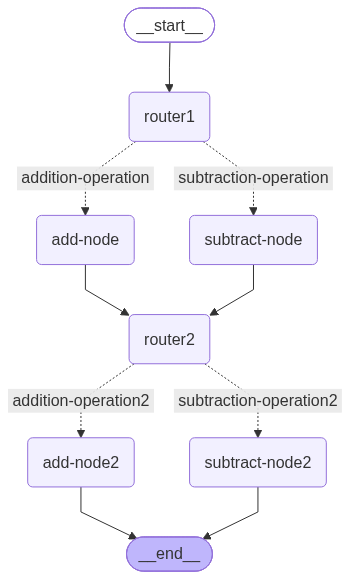

In [36]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [37]:
test_input = {
    "num1": 10,
    "num2": 5,
    "num3": 20,
    "num4": 8,
    "operator1": "+",
    "operator2": "-"
}

In [38]:
print(app.invoke(test_input))


{'num1': 10, 'num2': 5, 'num3': 20, 'num4': 8, 'operator1': '+', 'operator2': '-', 'final_num1': 15, 'final_num2': 12}
